# Baseline U-Net Training Pipeline — SAR Flood Segmentation

**Dataset:** Sen1Floods11 hand-labeled split (Bonafilia et al., 2020)  
**Model:** U-Net with ResNet-34 encoder, ImageNet-pretrained  
**Input:** [VV, VH, VH] — 3-channel, dB values normalized per-channel over train split  
**Loss:** BCE + Dice (1:1 weight), both masked on valid pixels (label != -1 and SAR != NaN)  
**Splits:** Official event-stratified splits from GCS (train=252, val=89, test=90 tiles)  
**Output:**
- Best checkpoint: `checkpoints/baseline_unet_resnet34.pt` (by val IoU)
- Metrics log: `logs/baseline_metrics.csv`

**Expected runtime on A40 (47.7 GB):** ~3–4 hours for 50 epochs at batch size 16 (512×512 tiles).

**Ablation targets — do NOT change in this notebook:**
- Third channel (currently VH-replicate)
- Speckle filtering (none: model sees raw dB)
- Loss weights (1:1)
- Optimizer/scheduler (Adam, no scheduler)

Run cells top to bottom. Download skips files already present locally.

In [1]:
import os
import csv
import json
import random
import time
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import rasterio
import gcsfs
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchmetrics.classification import (
    BinaryJaccardIndex,
    BinaryF1Score,
    BinaryPrecision,
    BinaryRecall,
)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

/home/dalmanza/ImagenesYVision/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/dalmanza/ImagenesYVision/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Device : cuda:1
GPU    : NVIDIA A40
VRAM   : 47.7 GB


## 1. Configuration

In [ ]:
ROOT      = Path('.')
DATA_DIR  = ROOT / 'data' / 'sen1floods11' / 'HandLabeled'
LABEL_DIR = DATA_DIR / 'LabelHand'
SPLITS_DIR= DATA_DIR / 'splits'

# --- Filter selection: uncomment the variant you want to run ---
S1_DIR = ROOT / 'data' / 'sen1floods11_filtered' / 'median' / 'S1Hand'   # Median 3x3
# S1_DIR = ROOT / 'data' / 'sen1floods11_filtered' / 'lee' / 'S1Hand'    # Lee n=7
# S1_DIR = DATA_DIR / 'S1Hand'                                             # No filter (original)

# Outputs are scoped per filter so runs never overwrite each other
_filter_tag  = S1_DIR.parts[-2]   # 'median', 'lee', or 'HandLabeled'
NORM_STATS_PATH = DATA_DIR / f'norm_stats_{_filter_tag}.json'
CHECKPOINT   = ROOT / 'checkpoints' / f'unet_resnet34_{_filter_tag}.pt'
METRICS_CSV  = ROOT / 'logs'        / f'metrics_{_filter_tag}.csv'

GCS_S1     = 'gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/'
GCS_LABEL  = 'gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/'
GCS_SPLITS = 'gs://sen1floods11/v1.1/splits/flood_handlabeled/'

BATCH_SIZE   = 16
NUM_EPOCHS   = 50
LR           = 1e-4
NUM_WORKERS  = 4
LABEL_NODATA = -1

for d in [S1_DIR, LABEL_DIR, SPLITS_DIR, CHECKPOINT.parent, METRICS_CSV.parent]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Filter variant  : {_filter_tag}')
print(f'S1_DIR          : {S1_DIR}')
print(f'Norm stats path : {NORM_STATS_PATH}')
print(f'Checkpoint      : {CHECKPOINT}')
print(f'Metrics CSV     : {METRICS_CSV}')
print('Directories ready.')

Filter variant  : lee
S1_DIR          : data/sen1floods11_filtered/lee/S1Hand
Norm stats path : data/sen1floods11/HandLabeled/norm_stats_lee.json
Checkpoint      : checkpoints/unet_resnet34_lee.pt
Metrics CSV     : logs/metrics_lee.csv
Directories ready.


## 2. Data download

Downloads all HandLabeled tiles and the official split CSVs from the public GCS bucket.  
Files already present locally are skipped.

In [3]:
def download_directory(
    fs: gcsfs.GCSFileSystem,
    gcs_prefix: str,
    local_dir: Path,
) -> tuple:
    """Download all files under gcs_prefix to local_dir, skipping existing files."""
    remote_files = fs.glob(gcs_prefix + '*')
    downloaded = skipped = 0
    for remote_path in tqdm(remote_files, desc=f'  {local_dir.name}'):
        fname = remote_path.split('/')[-1]
        local_path = local_dir / fname
        if local_path.exists():
            skipped += 1
            continue
        with fs.open(remote_path, 'rb') as src, open(local_path, 'wb') as dst:
            dst.write(src.read())
        downloaded += 1
    return downloaded, skipped


fs = gcsfs.GCSFileSystem(token='anon')

print('Downloading S1Hand tiles...')
n_dl, n_sk = download_directory(fs, GCS_S1, S1_DIR)
print(f'  downloaded={n_dl}  skipped={n_sk}')

print('Downloading LabelHand tiles...')
n_dl, n_sk = download_directory(fs, GCS_LABEL, LABEL_DIR)
print(f'  downloaded={n_dl}  skipped={n_sk}')

print('Downloading split CSVs...')
for csv_name in ['flood_train_data.csv', 'flood_valid_data.csv', 'flood_test_data.csv']:
    local_csv = SPLITS_DIR / csv_name
    if not local_csv.exists():
        with fs.open(GCS_SPLITS + csv_name, 'rb') as src, open(local_csv, 'wb') as dst:
            dst.write(src.read())
        print(f'  {csv_name} downloaded')
    else:
        print(f'  {csv_name} already exists')

print(f'\nS1Hand tiles   : {len(list(S1_DIR.glob("*.tif")))}')
print(f'LabelHand tiles: {len(list(LABEL_DIR.glob("*.tif")))}')

KeyboardInterrupt: 

## 3. Normalization statistics

Per-channel (VV, VH) mean and std computed over the **train split only**, ignoring NaN pixels.  
Cached to a file named after the active filter variant; reloaded on subsequent runs.  
**Must be recomputed for each filter** — filtered data has slightly different statistics.

In [ ]:
def load_split_csv(csv_path: Path) -> list:
    """Return list of (s1_filename, label_filename) from a Sen1Floods11 split CSV."""
    df = pd.read_csv(csv_path, header=None, names=['s1', 'label'])
    return list(zip(df['s1'].tolist(), df['label'].tolist()))


def compute_norm_stats(pairs: list, s1_dir: Path) -> dict:
    """Welford online mean/std per channel over the given split, ignoring NaN pixels."""
    count = np.zeros(2, dtype=np.float64)
    mean  = np.zeros(2, dtype=np.float64)
    M2    = np.zeros(2, dtype=np.float64)

    for s1_fname, _ in tqdm(pairs, desc='Computing norm stats'):
        fpath = s1_dir / s1_fname
        if not fpath.exists():
            raise FileNotFoundError(f'Missing tile: {fpath}')
        with rasterio.open(fpath) as src:
            vv = src.read(1).astype(np.float64).ravel()
            vh = src.read(2).astype(np.float64).ravel()
        for ch_idx, ch_data in enumerate([vv, vh]):
            valid = ch_data[~np.isnan(ch_data)]
            for x in valid:
                count[ch_idx] += 1
                delta = x - mean[ch_idx]
                mean[ch_idx] += delta / count[ch_idx]
                M2[ch_idx] += delta * (x - mean[ch_idx])

    std = np.sqrt(M2 / (count - 1))
    return {
        'mean_vv': float(mean[0]), 'std_vv': float(std[0]),
        'mean_vh': float(mean[1]), 'std_vh': float(std[1]),
    }


train_pairs = load_split_csv(SPLITS_DIR / 'flood_train_data.csv')
val_pairs   = load_split_csv(SPLITS_DIR / 'flood_valid_data.csv')
test_pairs  = load_split_csv(SPLITS_DIR / 'flood_test_data.csv')
print(f'Split sizes — train={len(train_pairs)}  val={len(val_pairs)}  test={len(test_pairs)}')

if NORM_STATS_PATH.exists():
    with open(NORM_STATS_PATH) as f:
        norm_stats = json.load(f)
    print(f'Loaded cached normalization stats from {NORM_STATS_PATH.name}')
else:
    print(f'Computing normalization stats for variant "{_filter_tag}"...')
    norm_stats = compute_norm_stats(train_pairs, S1_DIR)
    with open(NORM_STATS_PATH, 'w') as f:
        json.dump(norm_stats, f, indent=2)
    print(f'Cached to {NORM_STATS_PATH}')

print(f"\nVV  mean={norm_stats['mean_vv']:.4f}  std={norm_stats['std_vv']:.4f} dB")
print(f"VH  mean={norm_stats['mean_vh']:.4f}  std={norm_stats['std_vh']:.4f} dB")

Split sizes — train=252  val=89  test=90
Computing normalization stats for variant "median"...


Computing norm stats:   0%|          | 0/252 [00:00<?, ?it/s]

Cached to data/sen1floods11/HandLabeled/norm_stats_median.json

VV  mean=-10.3384  std=3.7709 dB
VH  mean=-17.1323  std=4.3414 dB


## 4. Dataset class

In [ ]:
class Sen1Floods11Dataset(Dataset):
    """PyTorch Dataset for the Sen1Floods11 hand-labeled split.

    Returns:
        image      : float32 (3, H, W) — [VV_norm, VH_norm, VH_norm]
        label      : long    (H, W)    — {-1=nodata, 0=dry, 1=flood}
        valid_mask : bool    (H, W)    — True where label!=-1 AND SAR not NaN
    """

    def __init__(
        self,
        pairs: list,
        s1_dir: Path,
        label_dir: Path,
        mean_vv: float,
        std_vv: float,
        mean_vh: float,
        std_vh: float,
        transform: Optional[A.Compose] = None,
    ) -> None:
        self.pairs     = pairs
        self.s1_dir    = s1_dir
        self.label_dir = label_dir
        self.mean_vv   = mean_vv
        self.std_vv    = std_vv
        self.mean_vh   = mean_vh
        self.std_vh    = std_vh
        self.transform = transform

    def __len__(self) -> int:
        return len(self.pairs)

    def __getitem__(self, idx: int) -> dict:
        s1_fname, lbl_fname = self.pairs[idx]

        with rasterio.open(self.s1_dir / s1_fname) as src:
            vv = src.read(1).astype(np.float32)  # already in dB
            vh = src.read(2).astype(np.float32)

        with rasterio.open(self.label_dir / lbl_fname) as src:
            label = src.read(1).astype(np.int16)

        # Build valid_mask before normalization while NaN flags are intact
        sar_valid  = ~np.isnan(vv) & ~np.isnan(vh)
        valid_mask = sar_valid & (label != LABEL_NODATA)

        # Z-score normalization with train-split statistics
        vv = (vv - self.mean_vv) / self.std_vv
        vh = (vh - self.mean_vh) / self.std_vh

        # Replace NaN with 0 after normalization so they do not propagate into the loss
        vv = np.where(np.isnan(vv), 0.0, vv)
        vh = np.where(np.isnan(vh), 0.0, vh)

        # Third channel: replicate VH (ablation target — keep minimal here)
        image = np.stack([vv, vh, vh], axis=-1)  # (H, W, 3) for albumentations

        # Shift label to uint8 for albumentations: nodata(-1)->0, dry(0)->1, flood(1)->2
        label_u8 = (label.astype(np.int32) + 1).astype(np.uint8)
        valid_u8 = valid_mask.astype(np.uint8)

        if self.transform is not None:
            aug      = self.transform(image=image, masks=[label_u8, valid_u8])
            image    = aug['image']
            label_u8 = aug['masks'][0]
            valid_u8 = aug['masks'][1]
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()

        if isinstance(label_u8, torch.Tensor):
            label_out = label_u8.long() - 1
            valid_out = valid_u8.bool()
        else:
            label_out = torch.from_numpy(label_u8.astype(np.int64)) - 1
            valid_out = torch.from_numpy(valid_u8.astype(bool))

        return {
            'image':      image.float(),
            'label':      label_out,
            'valid_mask': valid_out,
        }


def build_augmentation_train() -> A.Compose:
    """Geometric-only augmentations applied identically to image and masks."""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        ToTensorV2(transpose_mask=False),
    ])


def build_augmentation_eval() -> A.Compose:
    return A.Compose([ToTensorV2(transpose_mask=False)])


def build_dataset(pairs: list, transform: A.Compose) -> Sen1Floods11Dataset:
    return Sen1Floods11Dataset(
        pairs=pairs,
        s1_dir=S1_DIR,
        label_dir=LABEL_DIR,
        mean_vv=norm_stats['mean_vv'],
        std_vv=norm_stats['std_vv'],
        mean_vh=norm_stats['mean_vh'],
        std_vh=norm_stats['std_vh'],
        transform=transform,
    )


train_ds = build_dataset(train_pairs, build_augmentation_train())
val_ds   = build_dataset(val_pairs,   build_augmentation_eval())
test_ds  = build_dataset(test_pairs,  build_augmentation_eval())

print(f'Dataset sizes: train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

sample = train_ds[0]
print(f"image shape : {sample['image'].shape}  dtype={sample['image'].dtype}")
print(f"label shape : {sample['label'].shape}  dtype={sample['label'].dtype}")
print(f"valid_mask  : {sample['valid_mask'].shape}  dtype={sample['valid_mask'].dtype}")
print(f"label unique: {sample['label'].unique().tolist()}")

Dataset sizes: train=252  val=89  test=90
image shape : torch.Size([3, 512, 512])  dtype=torch.float32
label shape : torch.Size([512, 512])  dtype=torch.int64
valid_mask  : torch.Size([512, 512])  dtype=torch.bool
label unique: [-1, 0, 1]


## 5. DataLoaders

In [ ]:
g = torch.Generator()
g.manual_seed(SEED)


def seed_worker(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
    worker_init_fn=seed_worker, generator=g,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 16
Val batches   : 6
Test batches  : 6


## 6. Model, loss, optimizer

In [ ]:
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,  # raw logits; BCEWithLogitsLoss applies sigmoid internally
).to(DEVICE)

bce_fn  = nn.BCEWithLogitsLoss(reduction='none')
dice_fn = DiceLoss(mode='binary', from_logits=True, ignore_index=LABEL_NODATA)


def combined_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    valid_mask: torch.Tensor,
) -> torch.Tensor:
    """BCE + Dice (equal weight). Both ignore pixels where valid_mask is False.

    logits     : (B, 1, H, W) float
    labels     : (B, H, W)    long  {-1=nodata, 0=dry, 1=flood}
    valid_mask : (B, H, W)    bool
    """
    # Clamp nodata to 0 before BCE — valid_mask zeros the gradient anyway
    target_bce = labels.float().clamp(min=0.0).unsqueeze(1)   # (B,1,H,W)
    bce_per_px = bce_fn(logits, target_bce)                    # (B,1,H,W)
    mask_4d    = valid_mask.unsqueeze(1).float()               # (B,1,H,W)
    bce        = (bce_per_px * mask_4d).sum() / mask_4d.sum().clamp(min=1.0)

    # DiceLoss with ignore_index=-1 skips nodata pixels natively
    dice = dice_fn(logits, labels.long())

    return bce + dice


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(f'Optimizer           : Adam  lr={LR}')

Trainable parameters: 24,436,369
Optimizer           : Adam  lr=0.0001


## 7. Metric helpers

In [ ]:
def build_metrics(device: torch.device) -> dict:
    return {
        'iou':       BinaryJaccardIndex(threshold=0.5).to(device),
        'f1':        BinaryF1Score(threshold=0.5).to(device),
        'precision': BinaryPrecision(threshold=0.5).to(device),
        'recall':    BinaryRecall(threshold=0.5).to(device),
    }


def update_metrics(
    metrics: dict,
    logits: torch.Tensor,
    labels: torch.Tensor,
    valid_mask: torch.Tensor,
) -> None:
    """Feed only valid pixels into torchmetrics accumulators."""
    probs       = torch.sigmoid(logits).squeeze(1)  # (B, H, W)
    probs_flat  = probs[valid_mask]
    labels_flat = labels[valid_mask]                # 0 or 1 at valid positions
    for m in metrics.values():
        m.update(probs_flat, labels_flat)


def compute_dice(
    logits: torch.Tensor,
    labels: torch.Tensor,
    valid_mask: torch.Tensor,
    threshold: float = 0.5,
) -> float:
    """2*TP / (2*TP + FP + FN) over valid pixels."""
    preds = (torch.sigmoid(logits).squeeze(1) >= threshold).long()
    p = preds[valid_mask]
    g = labels[valid_mask]
    tp = (p * g).sum().item()
    fp = (p * (1 - g)).sum().item()
    fn = ((1 - p) * g).sum().item()
    return 2 * tp / (2 * tp + fp + fn + 1e-8)


val_metrics = build_metrics(DEVICE)
print('Metrics ready:', list(val_metrics.keys()))

Metrics ready: ['iou', 'f1', 'precision', 'recall']


## 8. Training and validation loops

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    scaler: torch.cuda.amp.GradScaler,
    device: torch.device,
    epoch: int,
) -> float:
    model.train()
    total_loss = 0.0
    with tqdm(loader, desc=f'  Train E{epoch:02d}', leave=False) as pbar:
        for batch in pbar:
            images     = batch['image'].to(device, non_blocking=True)
            labels     = batch['label'].to(device, non_blocking=True)
            valid_mask = batch['valid_mask'].to(device, non_blocking=True)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(images)
                loss   = combined_loss(logits, labels, valid_mask)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            pbar.set_postfix(loss=f'{loss.item():.4f}')

    return total_loss / len(loader)


@torch.inference_mode()
def validate(
    model: nn.Module,
    loader: DataLoader,
    metrics: dict,
    device: torch.device,
    epoch: int,
) -> dict:
    model.eval()
    total_loss = 0.0
    dice_accum = 0.0

    for m in metrics.values():
        m.reset()

    with tqdm(loader, desc=f'  Val   E{epoch:02d}', leave=False) as pbar:
        for batch in pbar:
            images     = batch['image'].to(device, non_blocking=True)
            labels     = batch['label'].to(device, non_blocking=True)
            valid_mask = batch['valid_mask'].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                logits = model(images)
                loss   = combined_loss(logits, labels, valid_mask)

            total_loss += loss.item()
            update_metrics(metrics, logits, labels, valid_mask)
            dice_accum += compute_dice(logits, labels, valid_mask)

    n = len(loader)
    return {
        'val_loss': total_loss / n,
        'val_iou':  metrics['iou'].compute().item(),
        'val_f1':   metrics['f1'].compute().item(),
        'val_dice': dice_accum / n,
        'val_prec': metrics['precision'].compute().item(),
        'val_rec':  metrics['recall'].compute().item(),
    }

## 9. Training — 50 epochs

In [ ]:
print('Expected runtime on A40 (47.7 GB): ~3-4 hours for 50 epochs at batch size 16.')
print(f'Train batches/epoch={len(train_loader)}  Val batches/epoch={len(val_loader)}')
print()

csv_fields = ['epoch', 'train_loss', 'val_loss', 'val_iou', 'val_dice', 'val_f1', 'val_prec', 'val_rec']
with open(METRICS_CSV, 'w', newline='') as f:
    csv.writer(f).writerow(csv_fields)

best_iou    = -1.0
best_epoch  = -1
t0_training = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    t0_epoch   = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE, epoch)
    val_res    = validate(model, val_loader, val_metrics, DEVICE, epoch)
    epoch_sec  = time.time() - t0_epoch

    elapsed = time.time() - t0_training
    eta_s   = (elapsed / epoch) * (NUM_EPOCHS - epoch)
    eta_str = time.strftime('%H:%M:%S', time.gmtime(eta_s))

    ckpt_flag = ''
    if val_res['val_iou'] > best_iou:
        best_iou   = val_res['val_iou']
        best_epoch = epoch
        torch.save(
            {
                'epoch':           epoch,
                'model_state':     model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'val_iou':         best_iou,
                'norm_stats':      norm_stats,
            },
            CHECKPOINT,
        )
        ckpt_flag = '  [BEST]'

    with open(METRICS_CSV, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f"{train_loss:.6f}",
            f"{val_res['val_loss']:.6f}",
            f"{val_res['val_iou']:.6f}",
            f"{val_res['val_dice']:.6f}",
            f"{val_res['val_f1']:.6f}",
            f"{val_res['val_prec']:.6f}",
            f"{val_res['val_rec']:.6f}",
        ])

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_res['val_loss']:.4f} | "
        f"val_IoU={val_res['val_iou']:.4f} | "
        f"val_Dice={val_res['val_dice']:.4f} | "
        f"val_F1={val_res['val_f1']:.4f} | "
        f"epoch_t={epoch_sec:.0f}s | ETA={eta_str}"
        f"{ckpt_flag}"
    )

total_time = time.time() - t0_training
print(f'\nTraining complete. Total time: {total_time/3600:.2f} h')
print(f'Best val IoU: {best_iou:.4f} at epoch {best_epoch}')
print(f'Checkpoint  : {CHECKPOINT}')

Expected runtime on A40 (47.7 GB): ~3-4 hours for 50 epochs at batch size 16.
Train batches/epoch=16  Val batches/epoch=6



  Train E01:   0%|          | 0/16 [00:00<?, ?it/s]

  Val   E01:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 01/50 | train_loss=1.4843 | val_loss=1.7925 | val_IoU=0.1559 | val_Dice=0.2530 | val_F1=0.2697 | epoch_t=7s | ETA=00:05:40  [BEST]


  Train E02:   0%|          | 0/16 [00:00<?, ?it/s]

...

  Val   E49:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 49/50 | train_loss=0.4099 | val_loss=0.4859 | val_IoU=0.6283 | val_Dice=0.7334 | val_F1=0.7717 | epoch_t=4s | ETA=00:00:04


  Train E50:   0%|          | 0/16 [00:00<?, ?it/s]

  Val   E50:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 50/50 | train_loss=0.4537 | val_loss=0.5772 | val_IoU=0.5722 | val_Dice=0.6811 | val_F1=0.7279 | epoch_t=4s | ETA=00:00:00

Training complete. Total time: 0.06 h
Best val IoU: 0.6718 at epoch 40
Checkpoint  : checkpoints/unet_resnet34_median.pt


## 10. Test set evaluation

In [ ]:
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint from epoch {ckpt['epoch']} (val IoU={ckpt['val_iou']:.4f})")

test_metrics  = build_metrics(DEVICE)
test_dice_acc = 0.0
test_loss_acc = 0.0

model.eval()
with torch.inference_mode():
    for batch in tqdm(test_loader, desc='Test evaluation'):
        images     = batch['image'].to(DEVICE, non_blocking=True)
        labels     = batch['label'].to(DEVICE, non_blocking=True)
        valid_mask = batch['valid_mask'].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(images)
            loss   = combined_loss(logits, labels, valid_mask)

        test_loss_acc += loss.item()
        update_metrics(test_metrics, logits, labels, valid_mask)
        test_dice_acc += compute_dice(logits, labels, valid_mask)

n = len(test_loader)
test_results = {
    'test_loss':  test_loss_acc / n,
    'test_iou':   test_metrics['iou'].compute().item(),
    'test_dice':  test_dice_acc / n,
    'test_f1':    test_metrics['f1'].compute().item(),
    'test_prec':  test_metrics['precision'].compute().item(),
    'test_rec':   test_metrics['recall'].compute().item(),
}

print()
print('=' * 55)
print('TEST SET RESULTS — Baseline U-Net ResNet-34')
print('=' * 55)
for k, v in test_results.items():
    print(f'  {k:<15}: {v:.4f}')
print('=' * 55)

Loaded checkpoint from epoch 40 (val IoU=0.6718)


Test evaluation:   0%|          | 0/6 [00:00<?, ?it/s]


TEST SET RESULTS — Baseline U-Net ResNet-34
  test_loss      : 0.4673
  test_iou       : 0.6862
  test_dice      : 0.7717
  test_f1        : 0.8139
  test_prec      : 0.8135
  test_rec       : 0.8143


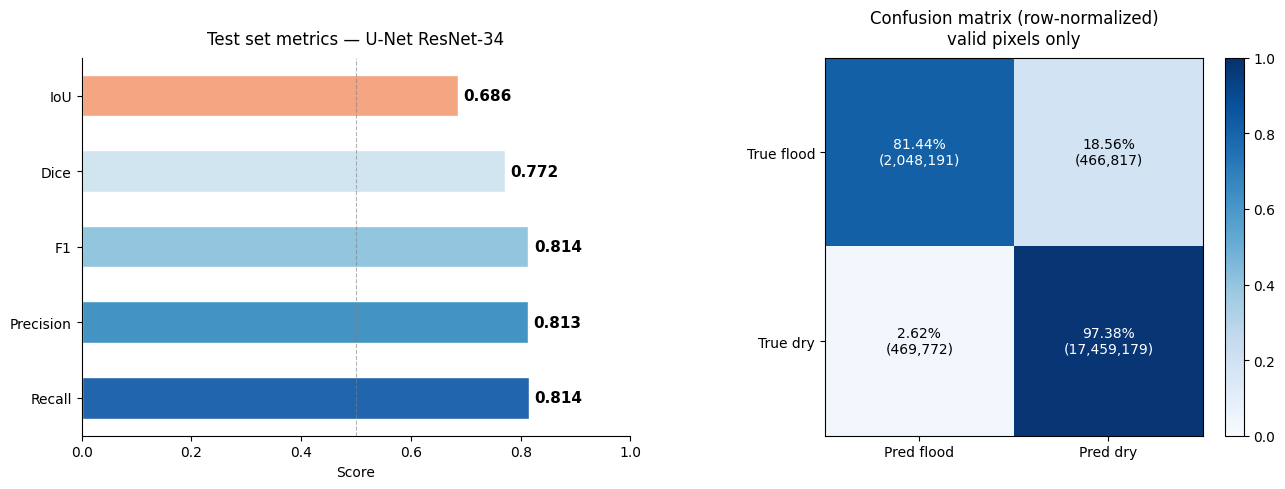

Saved to logs/test_results_visual.png


In [ ]:
# 10.1 — Visual summary of test set results

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: metric bar chart ---
metric_labels = ['IoU', 'Dice', 'F1', 'Precision', 'Recall']
metric_values = [
    test_results['test_iou'],
    test_results['test_dice'],
    test_results['test_f1'],
    test_results['test_prec'],
    test_results['test_rec'],
]
colors = ['#2166ac', '#4393c3', '#92c5de', '#d1e5f0', '#f4a582']
bars = axes[0].barh(metric_labels[::-1], metric_values[::-1], color=colors, edgecolor='white', height=0.55)
axes[0].set_xlim(0, 1)
axes[0].axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
for bar, val in zip(bars, metric_values[::-1]):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
axes[0].set_title('Test set metrics — U-Net ResNet-34', fontsize=12, pad=10)
axes[0].set_xlabel('Score')
axes[0].spines[['top', 'right']].set_visible(False)

# --- Right: confusion matrix from test_results (TP/FP/FN/TN derived from prec/rec/f1) ---
# Recover counts from precision and recall (unnormalized ratios).
# We don't have raw counts stored, so we recompute them from the full test set here.
all_probs  = []
all_labels = []

model.eval()
with torch.inference_mode():
    for batch in test_loader:
        images     = batch['image'].to(DEVICE, non_blocking=True)
        labels     = batch['label'].to(DEVICE, non_blocking=True)
        valid_mask = batch['valid_mask'].to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = model(images)
        probs = torch.sigmoid(logits).squeeze(1)
        all_probs.append(probs[valid_mask].cpu())
        all_labels.append(labels[valid_mask].cpu())

all_probs  = torch.cat(all_probs)
all_labels = torch.cat(all_labels)
preds      = (all_probs >= 0.5).long()

tp = int(((preds == 1) & (all_labels == 1)).sum())
fp = int(((preds == 1) & (all_labels == 0)).sum())
fn = int(((preds == 0) & (all_labels == 1)).sum())
tn = int(((preds == 0) & (all_labels == 0)).sum())

cm = np.array([[tp, fn], [fp, tn]], dtype=np.float64)
cm_norm = cm / cm.sum(axis=1, keepdims=True)  # row-normalize (recall-like)

im = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(['Pred flood', 'Pred dry'])
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['True flood', 'True dry'])
axes[1].set_title('Confusion matrix (row-normalized)\nvalid pixels only', fontsize=12, pad=10)

for i, row_counts in enumerate([[tp, fn], [fp, tn]]):
    for j, cnt in enumerate(row_counts):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2%}\n({cnt:,})',
                     ha='center', va='center', fontsize=10,
                     color='white' if cm_norm[i, j] > 0.55 else 'black')

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(ROOT / 'logs' / 'test_results_visual.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to logs/test_results_visual.png')

## 11. Sanity-check visualization

Three random test tiles: VV input | ground truth | prediction.

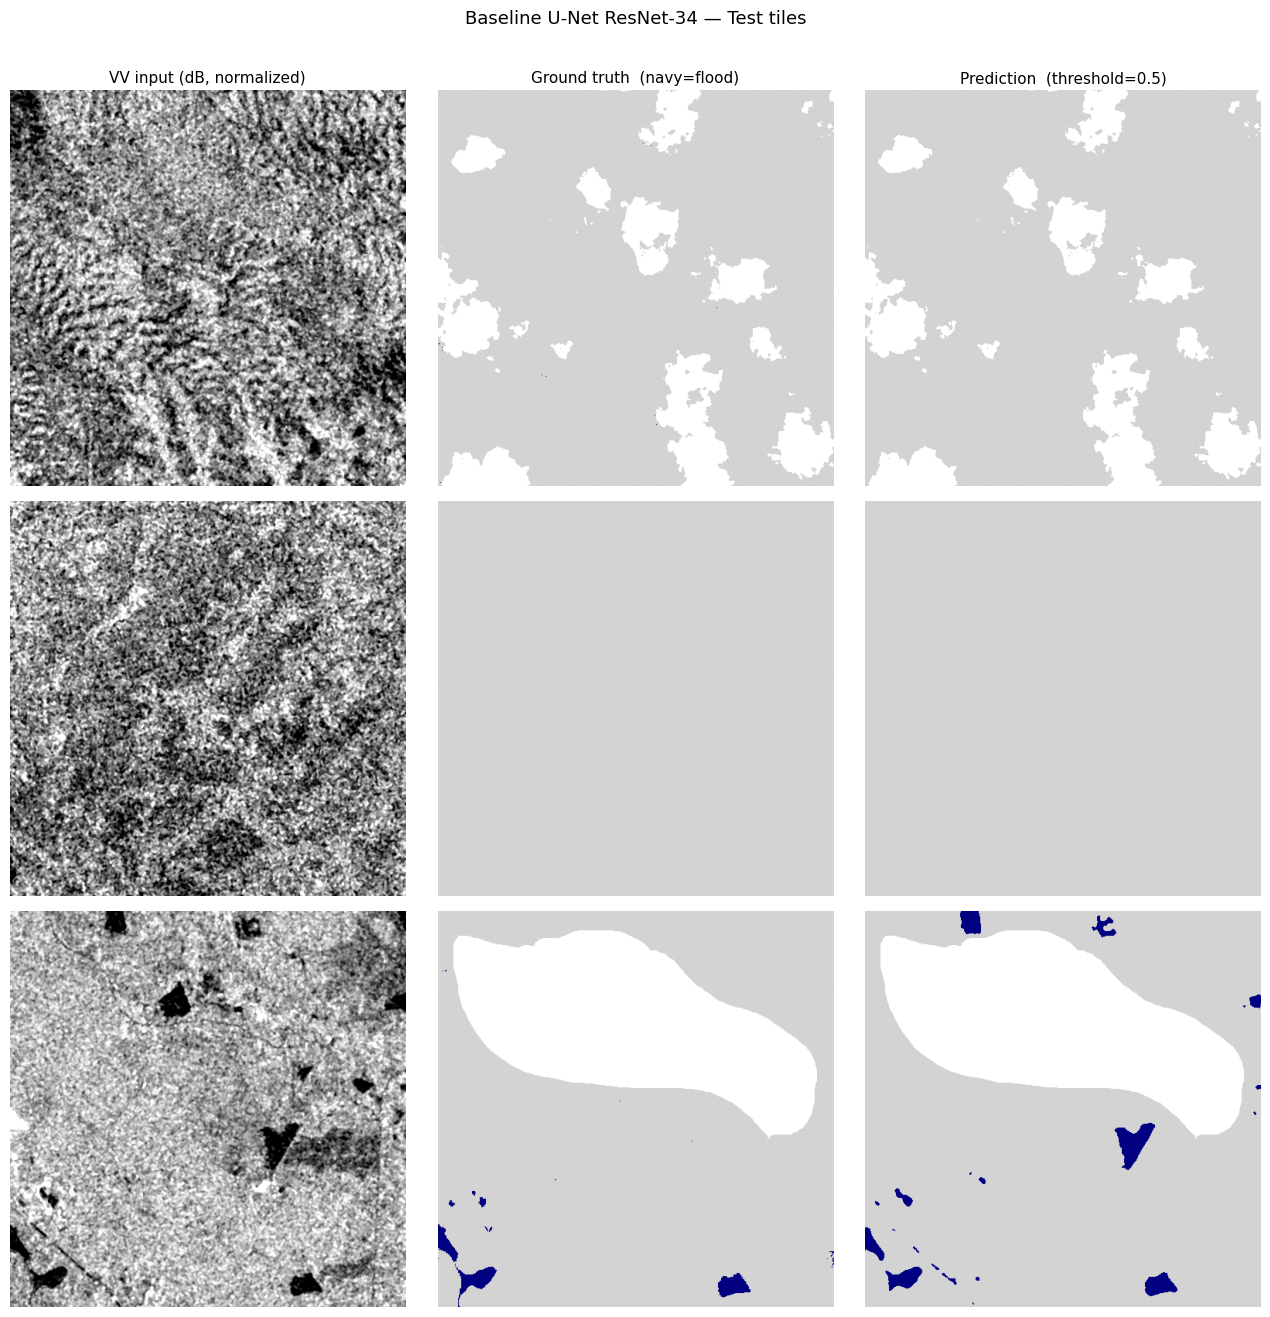

Saved to logs/viz_test_predictions.png


In [ ]:
def percentile_clip(x: np.ndarray, lo: float = 2.0, hi: float = 98.0) -> np.ndarray:
    """Normalize to [0,1] using percentiles; NaN pixels become 0 (black)."""
    valid_vals = x[~np.isnan(x)]
    if len(valid_vals) == 0:
        return np.zeros_like(x)
    vmin = np.nanpercentile(x, lo)
    vmax = np.nanpercentile(x, hi)
    out  = np.clip((x - vmin) / (vmax - vmin + 1e-10), 0, 1)
    out[np.isnan(x)] = 0.0
    return out


rng         = np.random.default_rng(SEED)
viz_indices = rng.choice(len(test_ds), size=3, replace=False).tolist()
cmap_mask   = mcolors.ListedColormap(['lightgray', 'navy', 'white'])

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
axes[0, 0].set_title('VV input (dB, normalized)', fontsize=11)
axes[0, 1].set_title('Ground truth  (navy=flood)', fontsize=11)
axes[0, 2].set_title('Prediction  (threshold=0.5)', fontsize=11)

model.eval()
with torch.inference_mode():
    for row, tile_idx in enumerate(viz_indices):
        s1_fname, _ = test_pairs[tile_idx]

        with rasterio.open(S1_DIR / s1_fname) as src:
            vv_raw = src.read(1).astype(np.float32)

        sample     = test_ds[tile_idx]
        label      = sample['label'].numpy()
        valid_mask = sample['valid_mask'].numpy()

        img_t = sample['image'].unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logit = model(img_t).squeeze().cpu().float().numpy()
        pred = (1.0 / (1.0 + np.exp(-logit)) >= 0.5).astype(np.float32)

        # Nodata pixels -> 2 = white in cmap_mask
        gt_disp   = np.where(valid_mask, label.astype(float), 2.0)
        pred_disp = np.where(valid_mask, pred, 2.0)

        tile_id = s1_fname.replace('_S1Hand.tif', '')
        axes[row, 0].imshow(percentile_clip(vv_raw), cmap='gray')
        axes[row, 0].set_ylabel(tile_id, fontsize=9, rotation=0, labelpad=90, va='center')
        axes[row, 0].axis('off')
        axes[row, 1].imshow(gt_disp,   cmap=cmap_mask, vmin=0, vmax=2)
        axes[row, 1].axis('off')
        axes[row, 2].imshow(pred_disp, cmap=cmap_mask, vmin=0, vmax=2)
        axes[row, 2].axis('off')

plt.suptitle('Baseline U-Net ResNet-34 — Test tiles', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'logs' / 'viz_test_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to logs/viz_test_predictions.png')

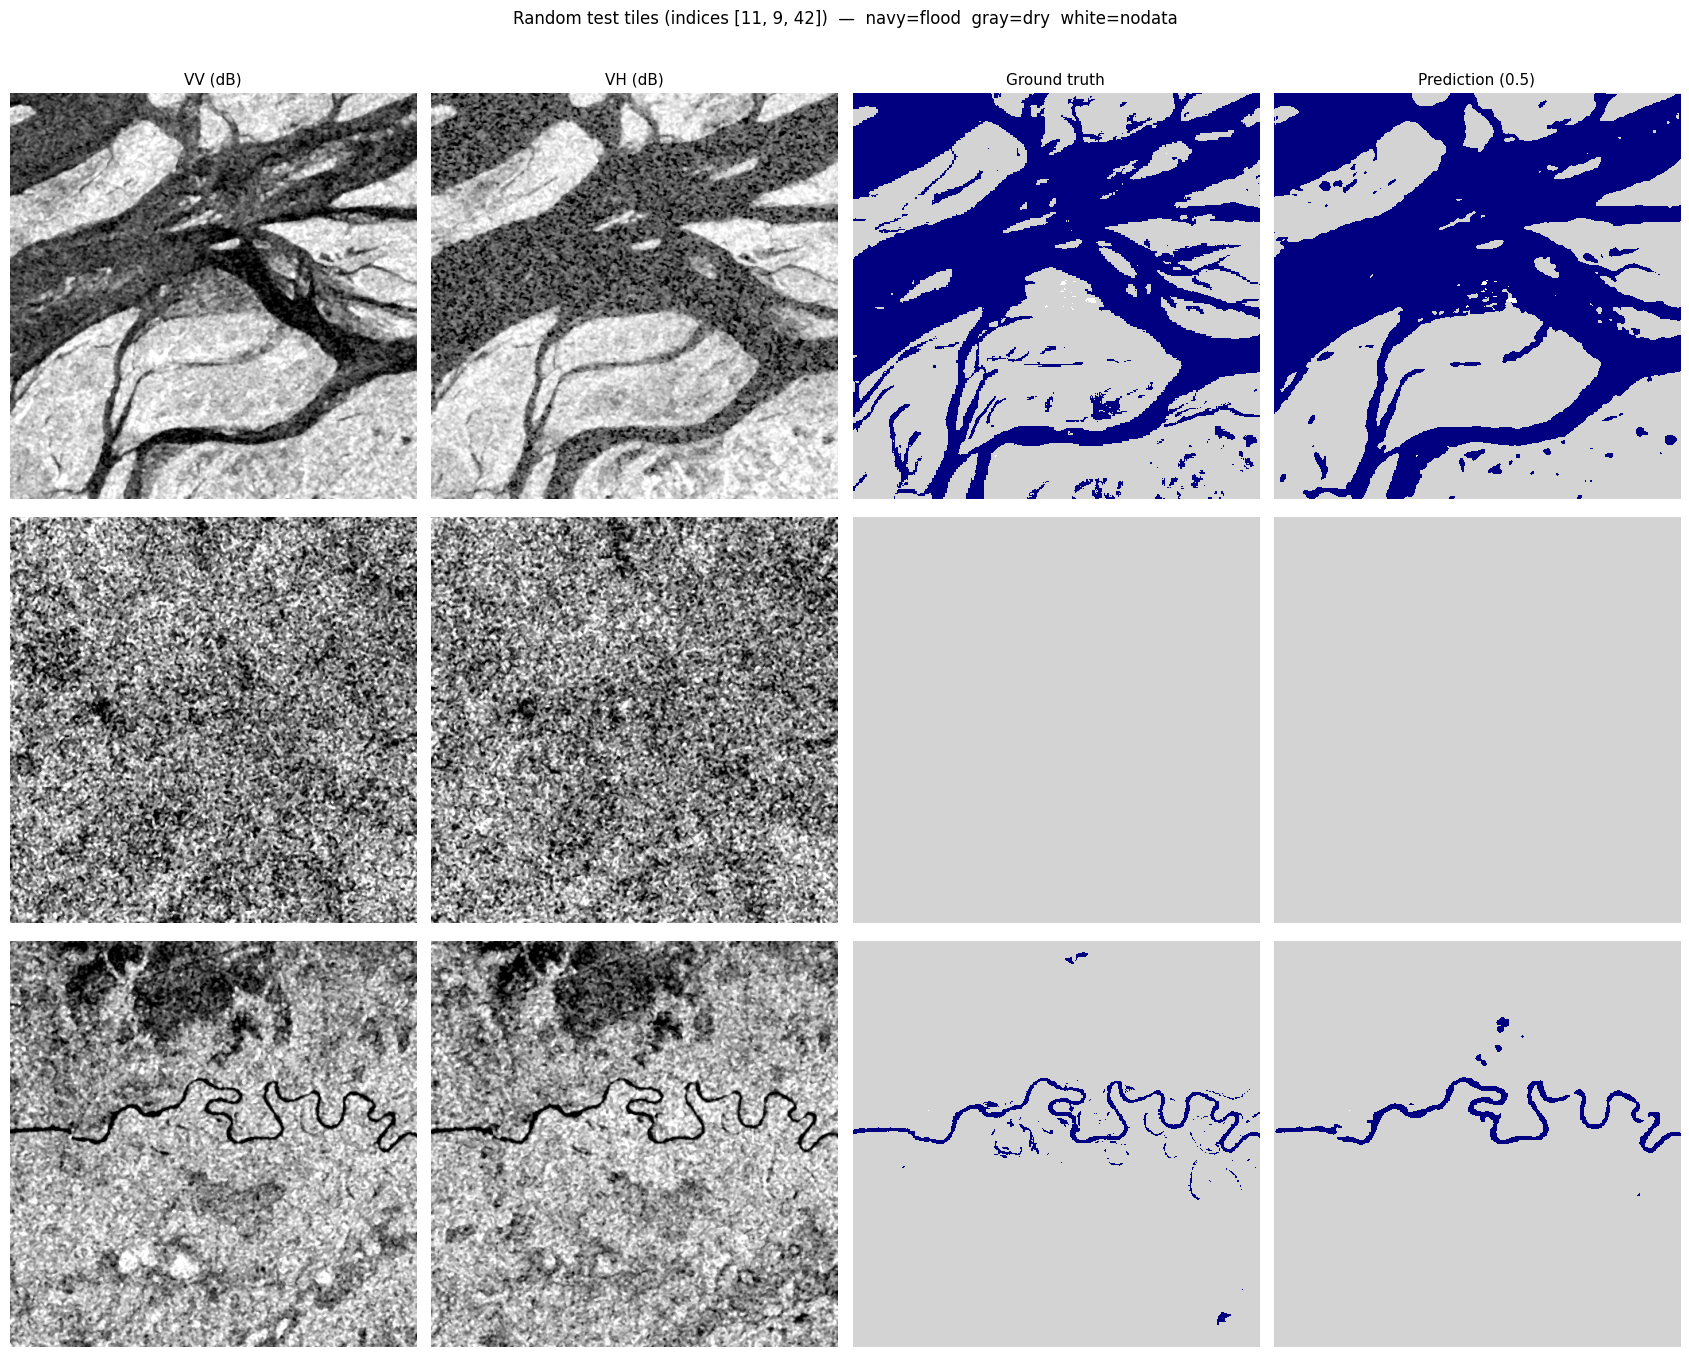

In [ ]:
# 11.1 — Random tile viewer (re-run this cell to see a different set each time)
# Uses system entropy — NOT seeded — so each execution picks 3 different tiles.

_rng      = np.random.default_rng()          # no seed argument → truly random
_n_tiles  = 3
_indices  = _rng.choice(len(test_ds), size=_n_tiles, replace=False).tolist()

def _predict_tile(idx: int) -> tuple:
    """Return (vv_raw, label, valid_mask, pred, tile_id) for a test tile."""
    s1_fname, _ = test_pairs[idx]
    with rasterio.open(S1_DIR / s1_fname) as src:
        vv_raw = src.read(1).astype(np.float32)
    sample = test_ds[idx]
    img_t  = sample['image'].unsqueeze(0).to(DEVICE)
    with torch.inference_mode(), torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
        logit = model(img_t).squeeze().cpu().float().numpy()
    pred = (1.0 / (1.0 + np.exp(-logit)) >= 0.5).astype(np.float32)
    return (
        vv_raw,
        sample['label'].numpy(),
        sample['valid_mask'].numpy(),
        pred,
        s1_fname.replace('_S1Hand.tif', ''),
    )

_cmap_mask = mcolors.ListedColormap(['lightgray', 'navy', 'white'])

# 4 columns: VV | VH | ground truth | prediction
fig, axes = plt.subplots(_n_tiles, 4, figsize=(17, 4.5 * _n_tiles))
axes[0, 0].set_title('VV (dB)',          fontsize=11)
axes[0, 1].set_title('VH (dB)',          fontsize=11)
axes[0, 2].set_title('Ground truth',     fontsize=11)
axes[0, 3].set_title('Prediction (0.5)', fontsize=11)

model.eval()
for row, tile_idx in enumerate(_indices):
    vv_raw, label, valid_mask, pred, tile_id = _predict_tile(tile_idx)

    s1_fname, _ = test_pairs[tile_idx]
    with rasterio.open(S1_DIR / s1_fname) as src:
        vh_raw = src.read(2).astype(np.float32)

    gt_disp   = np.where(valid_mask, label.astype(float), 2.0)
    pred_disp = np.where(valid_mask, pred, 2.0)

    # per-tile IoU (quick manual computation for the annotation)
    p_flat = pred[valid_mask].astype(np.int32)
    g_flat = label[valid_mask].astype(np.int32)
    _tp = int((p_flat * g_flat).sum())
    _fp = int((p_flat * (1 - g_flat)).sum())
    _fn = int(((1 - p_flat) * g_flat).sum())
    tile_iou = _tp / (_tp + _fp + _fn + 1e-8)
    flood_pct = 100.0 * g_flat.sum() / max(len(g_flat), 1)

    axes[row, 0].imshow(percentile_clip(vv_raw), cmap='gray')
    axes[row, 0].set_ylabel(f'{tile_id}\nIoU={tile_iou:.3f}  flood={flood_pct:.1f}%',
                            fontsize=8, rotation=0, labelpad=100, va='center')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(percentile_clip(vh_raw), cmap='gray')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(gt_disp,   cmap=_cmap_mask, vmin=0, vmax=2, interpolation='nearest')
    axes[row, 2].axis('off')

    axes[row, 3].imshow(pred_disp, cmap=_cmap_mask, vmin=0, vmax=2, interpolation='nearest')
    axes[row, 3].axis('off')

plt.suptitle(
    f'Random test tiles (indices {_indices})  —  navy=flood  gray=dry  white=nodata',
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

## 12. Learning curves

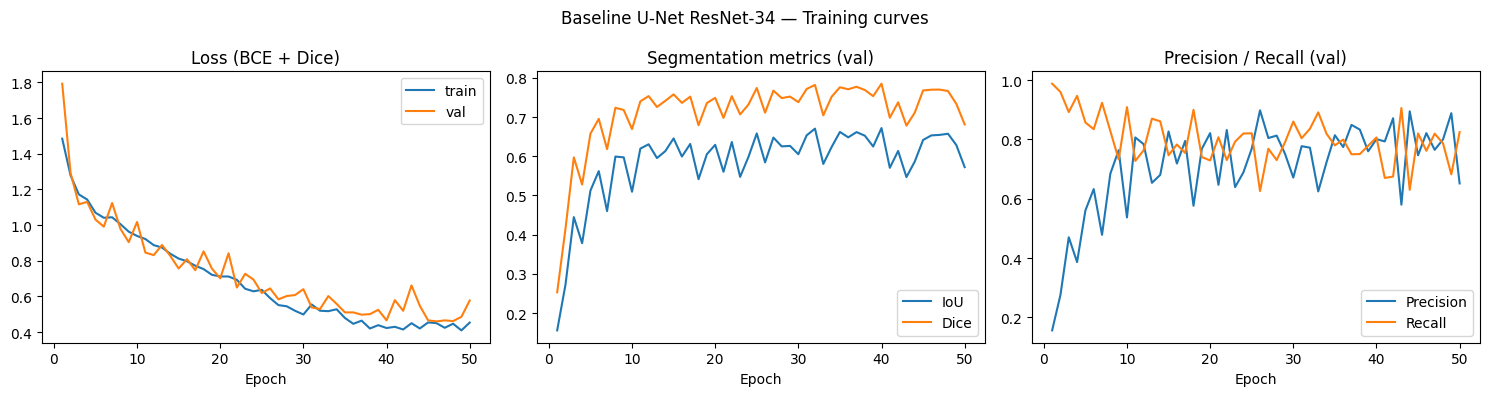

Saved to logs/training_curves.png


In [ ]:
metrics_df = pd.read_csv(METRICS_CSV)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(metrics_df['epoch'], metrics_df['train_loss'], label='train')
axes[0].plot(metrics_df['epoch'], metrics_df['val_loss'],   label='val')
axes[0].set_title('Loss (BCE + Dice)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(metrics_df['epoch'], metrics_df['val_iou'],  label='IoU')
axes[1].plot(metrics_df['epoch'], metrics_df['val_dice'], label='Dice')
axes[1].set_title('Segmentation metrics (val)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(metrics_df['epoch'], metrics_df['val_prec'], label='Precision')
axes[2].plot(metrics_df['epoch'], metrics_df['val_rec'],  label='Recall')
axes[2].set_title('Precision / Recall (val)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Baseline U-Net ResNet-34 — Training curves', fontsize=12)
plt.tight_layout()
plt.savefig(ROOT / 'logs' / 'training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to logs/training_curves.png')